# Titanic Dataset: Data Cleaning, EDA and Feature Engineering

## Problem statement
Load the dataset and:

1. Identify and handle missing values, duplicates, and obvious outliers.
2. Perform exploratory data analysis with at least four visualizations, including distributions, correlations, and group comparisons.
3. Engineer at least two new features that could help a future model.
4. Summarize five key insights in markdown/comments.

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset (1).csv


Load the dataset



In [ ]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'Titanic-Dataset.csv', 'Titanic-Dataset (1).csv', 'titanic_day1_project.zip', 'sample_data']


In [ ]:
def locate_dataset(filename="Titanic-Dataset.csv"):
    candidates = [Path(filename), Path.cwd() / filename]

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates.extend(kaggle_input.rglob(filename))

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"{filename} was not found. Upload it beside the notebook or add it as Kaggle input."
    )

DATA_PATH = locate_dataset()
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print(f"Dataset path: {DATA_PATH}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset path: Titanic-Dataset.csv
Shape: 891 rows × 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("Column data types:")
display(df.dtypes.to_frame("dtype"))

print("\nBasic summary:")
display(df.describe(include="all").T)

Column data types:


,dtype
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64



Basic summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [ ]:
missing_before = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(missing_percent=lambda x: (x["missing_count"] / len(df) * 100).round(2))
      .sort_values("missing_count", ascending=False)
)

print("Missing-value summary:")
display(missing_before)

exact_duplicates = df.duplicated().sum()
duplicate_passenger_ids = df["PassengerId"].duplicated().sum()

print(f"Exact duplicate rows: {exact_duplicates}")
print(f"Duplicate PassengerId values: {duplicate_passenger_ids}")

Missing-value summary:


,missing_count,missing_percent
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


Exact duplicate rows: 0
Duplicate PassengerId values: 0


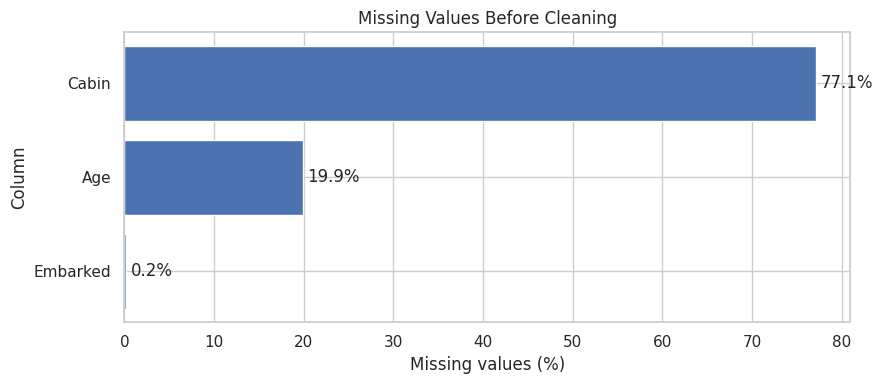

In [ ]:
# Visualization 1: missing-value distribution before cleaning
missing_plot = missing_before.query("missing_count > 0").sort_values("missing_percent")

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(missing_plot.index, missing_plot["missing_percent"])
ax.set(
    title="Missing Values Before Cleaning",
    xlabel="Missing values (%)",
    ylabel="Column"
)
for y_position, value in enumerate(missing_plot["missing_percent"]):
    ax.text(value + 0.5, y_position, f"{value:.1f}%", va="center")
plt.tight_layout()
plt.show()

Data-quality assessment

### Duplicate handling

In [ ]:
rows_before = len(df)
df = df.drop_duplicates().copy()
rows_removed = rows_before - len(df)

print(f"Duplicate rows removed: {rows_removed}")

Duplicate rows removed: 0


In [ ]:
# Extract title before imputing Age.
df["Title"] = (
    df["Name"]
      .str.extract(r",\s*([^.]*)\.", expand=False)
      .str.strip()
)

title_replacements = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",
    "Lady": "Rare",
    "Countess": "Rare",
    "Capt": "Rare",
    "Col": "Rare",
    "Don": "Rare",
    "Dr": "Rare",
    "Major": "Rare",
    "Rev": "Rare",
    "Sir": "Rare",
    "Jonkheer": "Rare",
    "Dona": "Rare",
}
df["Title"] = df["Title"].replace(title_replacements)

# Age: grouped median, with global median as a fallback.
age_group_median = df.groupby(["Title", "Pclass"])["Age"].transform("median")
df["Age"] = df["Age"].fillna(age_group_median)
df["Age"] = df["Age"].fillna(df["Age"].median())

# Embarked: mode.
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin: preserve informative missingness.
df["HasCabin"] = df["Cabin"].notna().astype(int)
df["Deck"] = df["Cabin"].str[0].fillna("U")
df["Cabin"] = df["Cabin"].fillna("Unknown")

print("Missing values after imputation:")
display(df.isna().sum().to_frame("missing_count").query("missing_count > 0"))

Missing values after imputation:


,missing_count


In [ ]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

numeric_check = ["Age", "Fare", "SibSp", "Parch"]
outlier_rows = []

for column in numeric_check:
    lower, upper = iqr_bounds(df[column])
    count = ((df[column] < lower) | (df[column] > upper)).sum()
    outlier_rows.append({
        "column": column,
        "lower_fence": round(lower, 3),
        "upper_fence": round(upper, 3),
        "flagged_values": int(count),
        "minimum": df[column].min(),
        "maximum": df[column].max(),
    })

outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary)

impossible_age_count = ((df["Age"] < 0) | (df["Age"] > 100)).sum()
print(f"Impossible age values (<0 or >100): {impossible_age_count}")

,column,lower_fence,upper_fence,flagged_values,minimum,maximum
0,Age,-2.625,60.375,22,0.42,80.0000
1,Fare,-26.724,65.634,116,0.00,512.3292
2,SibSp,-1.500,2.500,46,0.00,8.0000
3,Parch,0.000,0.000,213,0.00,6.0000


Impossible age values (<0 or >100): 0


In [ ]:
fare_lower, fare_upper = iqr_bounds(df["Fare"])
fare_lower = max(0, fare_lower)

df["Fare_Capped"] = df["Fare"].clip(lower=fare_lower, upper=fare_upper)
df["LogFare"] = np.log1p(df["Fare_Capped"])

print(f"Fare IQR upper fence used for capping: {fare_upper:.4f}")
print(f"Number of fare values capped: {(df['Fare'] > fare_upper).sum()}")

Fare IQR upper fence used for capping: 65.6344
Number of fare values capped: 116


In [ ]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["FarePerPerson"] = df["Fare_Capped"] / df["FamilySize"]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 50, 65, np.inf],
    labels=["Child", "Teen", "Young Adult", "Adult", "Older Adult", "Senior"],
    include_lowest=True
)

engineered_features = [
    "Title", "HasCabin", "Deck", "Fare_Capped", "LogFare",
    "FamilySize", "IsAlone", "FarePerPerson", "AgeGroup"
]

print("Engineered features:")
display(df[engineered_features].head())

Engineered features:


,Title,HasCabin,Deck,Fare_Capped,LogFare,FamilySize,IsAlone,FarePerPerson,AgeGroup
0,Mr,0,U,7.2500,2.110213,2,0,3.6250,Young Adult
1,Mrs,1,C,65.6344,4.199221,2,0,32.8172,Adult
2,Miss,0,U,7.9250,2.188856,1,1,7.9250,Young Adult
3,Mrs,1,C,53.1000,3.990834,2,0,26.5500,Young Adult
4,Mr,0,U,8.0500,2.202765,1,1,8.0500,Young Adult


Exploratory data analysis

The visualizations below cover distributions, group comparisons, and numeric correlations.

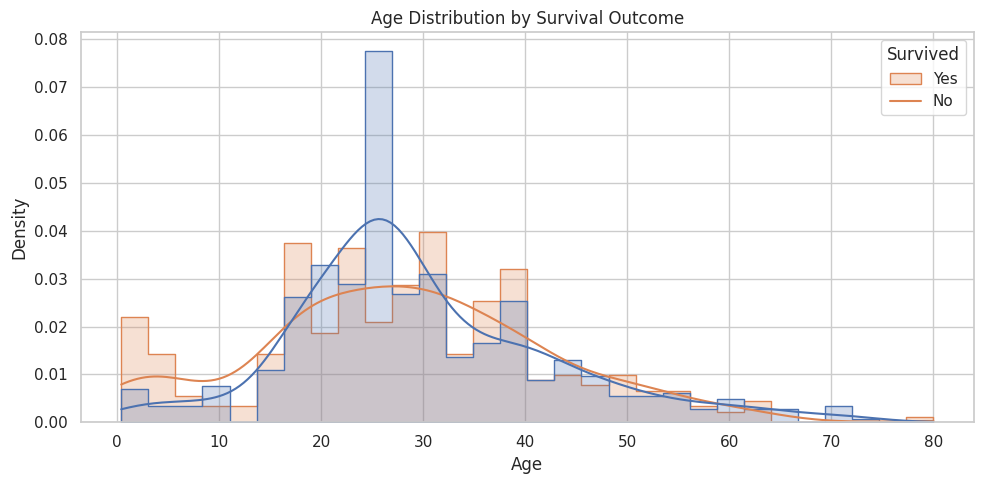

In [ ]:
# Visualization 2: age distribution split by survival outcome
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Age Distribution by Survival Outcome")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend(title="Survived", labels=["Yes", "No"])
plt.tight_layout()
plt.show()

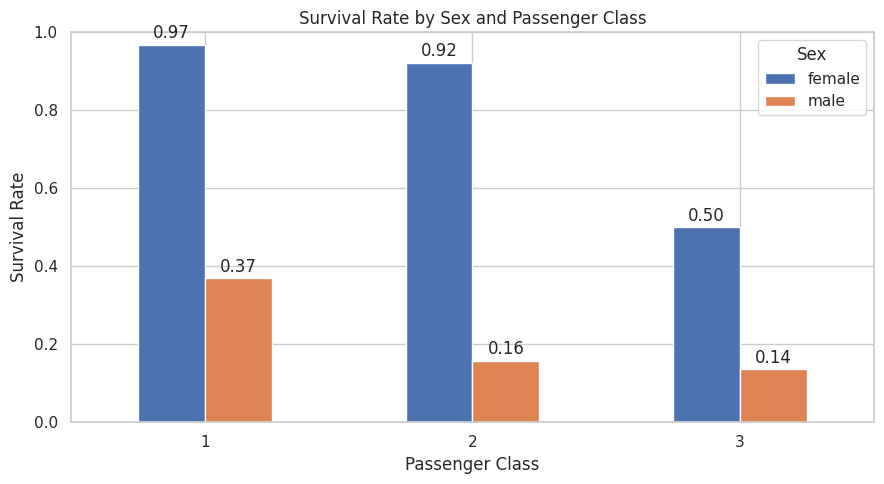

In [ ]:
# Visualization 3: group comparison — survival rate by sex and passenger class
survival_sex_class = (
    df.groupby(["Pclass", "Sex"])["Survived"]
      .mean()
      .unstack()
)

ax = survival_sex_class.plot(kind="bar", figsize=(9, 5))
ax.set(
    title="Survival Rate by Sex and Passenger Class",
    xlabel="Passenger Class",
    ylabel="Survival Rate",
    ylim=(0, 1)
)
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2)
plt.tight_layout()
plt.show()

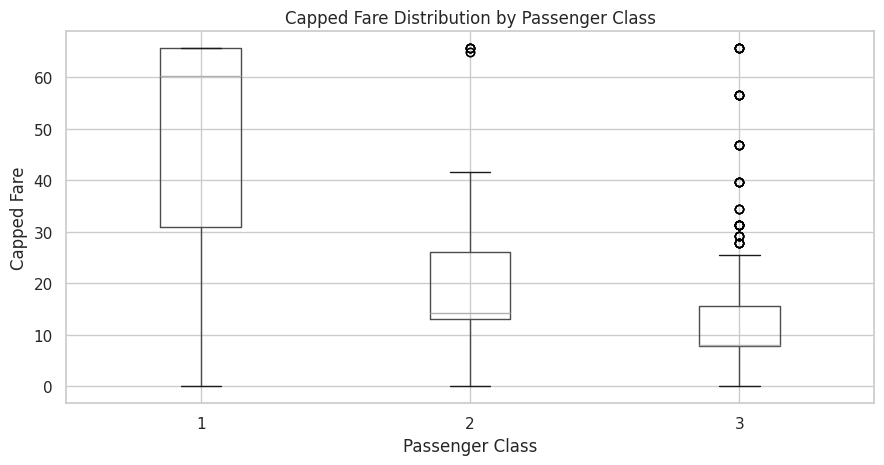

In [ ]:
# Visualization 4: fare distribution by passenger class
fig, ax = plt.subplots(figsize=(9, 5))
df.boxplot(column="Fare_Capped", by="Pclass", ax=ax)
ax.set(
    title="Capped Fare Distribution by Passenger Class",
    xlabel="Passenger Class",
    ylabel="Capped Fare"
)
fig.suptitle("")
plt.tight_layout()
plt.show()

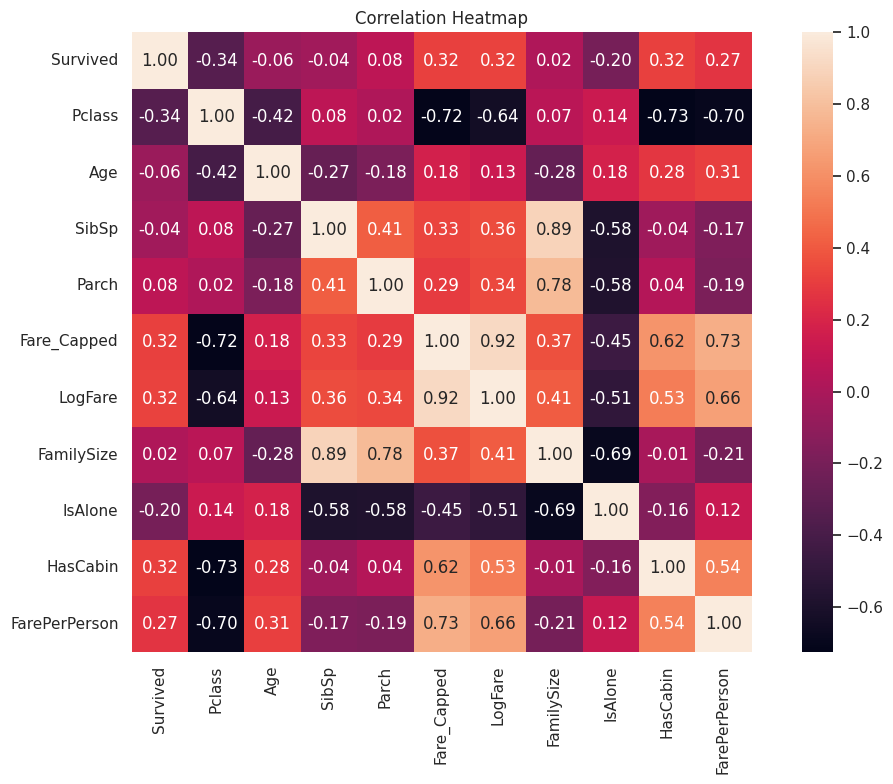

In [ ]:
# Visualization 5: correlation heatmap for numeric variables and engineered features
correlation_columns = [
    "Survived", "Pclass", "Age", "SibSp", "Parch",
    "Fare_Capped", "LogFare", "FamilySize", "IsAlone",
    "HasCabin", "FarePerPerson"
]

corr_matrix = df[correlation_columns].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    square=True
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

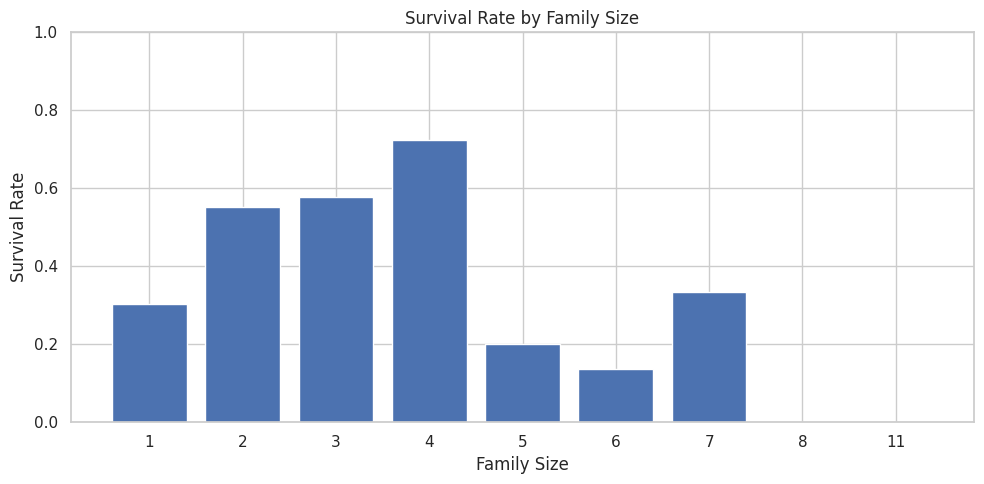

,FamilySize,SurvivalRate,PassengerCount
0,1,0.303538,537
1,2,0.552795,161
2,3,0.578431,102
3,4,0.724138,29
4,5,0.200000,15
5,6,0.136364,22
6,7,0.333333,12
7,8,0.000000,6
8,11,0.000000,7


In [ ]:
# Visualization 6: family-size group comparison
family_survival = (
    df.groupby("FamilySize", as_index=False)
      .agg(SurvivalRate=("Survived", "mean"), PassengerCount=("Survived", "size"))
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(family_survival["FamilySize"].astype(str), family_survival["SurvivalRate"])
ax.set(
    title="Survival Rate by Family Size",
    xlabel="Family Size",
    ylabel="Survival Rate",
    ylim=(0, 1)
)
plt.tight_layout()
plt.show()

display(family_survival)

In [ ]:
# Verify the insight calculations directly from the cleaned data.
insight_tables = {
    "Survival by sex": df.groupby("Sex")["Survived"].agg(["mean", "count"]),
    "Survival by passenger class": df.groupby("Pclass")["Survived"].agg(["mean", "count"]),
    "Survival by cabin availability": df.groupby("HasCabin")["Survived"].agg(["mean", "count"]),
    "Survival by travelling alone": df.groupby("IsAlone")["Survived"].agg(["mean", "count"]),
    "Survival by embarkation port": df.groupby("Embarked")["Survived"].agg(["mean", "count"]),
}

for title, table in insight_tables.items():
    print(f"\n{title}")
    display(table.assign(mean=lambda x: (x["mean"] * 100).round(2)))


Survival by sex


,mean,count
Sex,,
female,74.20,314
male,18.89,577



Survival by passenger class


,mean,count
Pclass,,
1,62.96,216
2,47.28,184
3,24.24,491



Survival by cabin availability


,mean,count
HasCabin,,
0,29.99,687
1,66.67,204



Survival by travelling alone


,mean,count
IsAlone,,
0,50.56,354
1,30.35,537



Survival by embarkation port


,mean,count
Embarked,,
C,55.36,168
Q,38.96,77
S,33.90,646


Final validation and export


In [ ]:
assert df.duplicated().sum() == 0, "Duplicate rows remain."
assert df.isna().sum().sum() == 0, "Missing values remain."
assert ((df["Age"] < 0) | (df["Age"] > 100)).sum() == 0, "Invalid age values remain."

output_path = Path("Titanic-Cleaned-Engineered.csv")
df.to_csv(output_path, index=False)

print(f"Final shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Remaining missing values: {df.isna().sum().sum()}")
print(f"Remaining exact duplicates: {df.duplicated().sum()}")
print(f"Cleaned dataset saved to: {output_path.resolve()}")

df.head()

Final shape: 891 rows × 21 columns
Remaining missing values: 0
Remaining exact duplicates: 0
Cleaned dataset saved to: /content/Titanic-Cleaned-Engineered.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,HasCabin,Deck,Fare_Capped,LogFare,FamilySize,IsAlone,FarePerPerson,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Mr,0,U,7.2500,2.110213,2,0,3.6250,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,1,C,65.6344,4.199221,2,0,32.8172,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Miss,0,U,7.9250,2.188856,1,1,7.9250,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,1,C,53.1000,3.990834,2,0,26.5500,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Mr,0,U,8.0500,2.202765,1,1,8.0500,Young Adult
